In [1]:
import numpy as np
import xarray as xr
from xso.parscans import run_xso_parscan, run_xso_stabilityscan


# --- 1. Run the IVP Scan ---
print("Running IVP scan...")
higherordermortality = np.linspace(0.003,0.07, 50)
ivp_param_values = [np.array([0, 0, 0, val]) for val in higherordermortality]
ivp_param_values2 = np.linspace(0.2,0.4, 30)


ivp_results = run_xso_parscan(
    model_file_name='Stocketal2008',
    model_name='model',
    model_setup_name='model_setup_ivp', # <-- Your IVP setup
    param_name='HigherOrderMortality__rate',
    param_values=ivp_param_values,
    param_name2='GGE__gge',
    param_values2=ivp_param_values2,
    processes=20
)

if ivp_results is None:
    raise RuntimeError("IVP scan failed. Aborting.")

PROGRESS: Completed 50/50 outer points. (HigherOrderMortality__rate = [0.         0.         0.         0.04538776]).

2D Scan complete. Total Time taken: 291.3027 seconds.


Calculating parameter fit from 'final_ivp_results'...
Minimum distance found: 0.027034900944835488
Generating parameter fit plot...


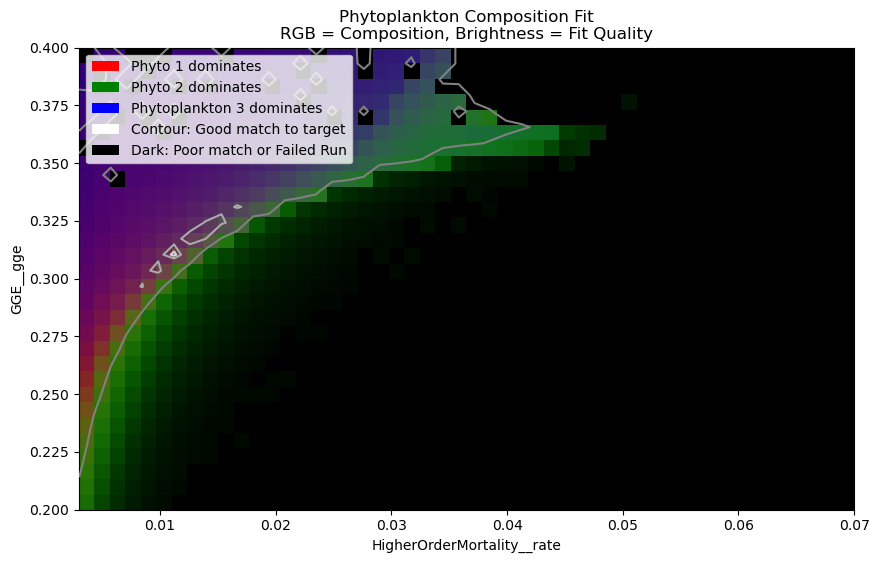

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import xarray as xr
import matplotlib.colors as mcolors

# Assumed Dataset:
final_ivp_results = ivp_results

# --- 1. GENERATE THE "FIT" DATA (from your IVP run) ---
print("Calculating parameter fit from 'final_ivp_results'...")

target_composition = np.array([0.402, 0.290, 0.308])

# --- FIX 1: Change time slice ---
start_time = 4000
end_time = 5000
# --- End Fix 1 ---

# Slice and average
biomass = final_ivp_results.Phytoplankton__biomass.isel(time=slice(start_time, end_time))
biomass_mean = biomass.mean(dim='time')

# --- FIX 2: Transpose to new dimensions ---
# Y-axis (rows) = N0__value
# X-axis (cols) = HigherOrderMortality__rate
biomass_mean = biomass_mean.transpose('GGE__gge', 'HigherOrderMortality__rate', 'phyto')
# --- End Fix 2 ---

# --- Normalize to relative composition ---
total_biomass = biomass_mean.sum(dim='phyto')
relative_composition = biomass_mean / total_biomass
relative_composition = relative_composition.fillna(0)

# --- Compute distance to target composition ---
# rel_np shape is now (n_n0, n_mortality, phyto)
rel_np = relative_composition.values
# dist shape is now (n_n0, n_mortality)
dist = np.linalg.norm(rel_np - target_composition, axis=2) 
print(f"Minimum distance found: {dist.min()}")

# --- Normalize and compute brightness for RGB plot ---
dist_max = np.percentile(dist, 95)
dist_clipped = np.clip(dist, 0, dist_max)
dist_norm = dist_clipped / dist_max
brightness = 1 - dist_norm
gamma = 0.5
brightness_gamma = brightness ** gamma
# rgb shape is now (n_n0, n_mortality, 3)
rgb = rel_np * brightness_gamma[..., np.newaxis]
rgb = np.nan_to_num(rgb, nan=0.0) # Failed runs (NaN) become black
rgb = np.clip(rgb, 0, 1)

# --- Prepare coordinate grids for contour ---
# --- FIX 2: Swap x_vals and y_vals ---
x_vals = biomass_mean.HigherOrderMortality__rate.values # X-axis
y_vals = biomass_mean.GGE__gge.values                 # Y-axis
X, Y = np.meshgrid(x_vals, y_vals) # X, Y, and dist now have shape (n_n0, n_mortality)
# --- End Fix 2 ---

# --- 2. CREATE THE PLOT ---
print("Generating parameter fit plot...")

plt.figure(figsize=(10, 6))
ax = plt.gca()

# Plot the RGB composition/fit as the base
# imshow will plot rgb[Y, X]
ax.imshow(rgb, origin='lower', aspect='auto',
          extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
          zorder=1)

# Overlay contour for perfect match
levels = [0.02, 0.05, 0.1, 0.5]
cmap = mcolors.LinearSegmentedColormap.from_list("grey_white", ["grey", "white"], N=256)
# contour(X, Y, dist) is still correct
cs = ax.contour(X, Y, dist, levels=levels, colors=cmap(np.linspace(1, 0, len(levels))), 
                linewidths=1.5, zorder=3)

# --- 3. LEGEND AND FINAL PLOT (No stability info) ---
# --- FIX 2: Swap axis labels ---
ax.set_xlabel('HigherOrderMortality__rate')
ax.set_ylabel('GGE__gge')
# --- End Fix 2 ---
ax.set_title('Phytoplankton Composition Fit\nRGB = Composition, Brightness = Fit Quality')
ax.grid(False)

legend_elements = [
    Patch(facecolor='red', label='Phyto 1 dominates'),
    Patch(facecolor='green', label='Phyto 2 dominates'),
    Patch(facecolor='blue', label='Phytoplankton 3 dominates'),
    Patch(facecolor='white', label='Contour: Good match to target'),
    Patch(facecolor='black', label='Dark: Poor match or Failed Run')
]
ax.legend(handles=legend_elements, loc='bottom right')

#plt.savefig("Final_Parameter_Fit_Only_Flipped_NEWRANGE.pdf", format='pdf', bbox_inches='tight')
plt.show()

Minimum distance found: 0.027034900944835488
Best fit found at index: (np.int64(16), np.int64(6))
Corresponding GGE__gge: 0.3103448275862069
Corresponding HigherOrderMortality__rate (scalar): 0.01120408163265306

--- Best Fit Run Extracted ---
<xarray.Dataset> Size: 3MB
Dimensions:                                         (zoo: 4, time: 5000,
                                                     phyto: 3, full: 7, clock: 2)
Coordinates:
    GGE__gge                                        float64 8B 0.3103
    HigherOrderMortality__rate                      float64 8B 0.0112
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 40kB 0.0 ....
  * zoo                                             (zoo) float64 32B 6.3 ......
Dimensions without coordinates: full
Data variables: (12/55)
    Core__solver_type                      

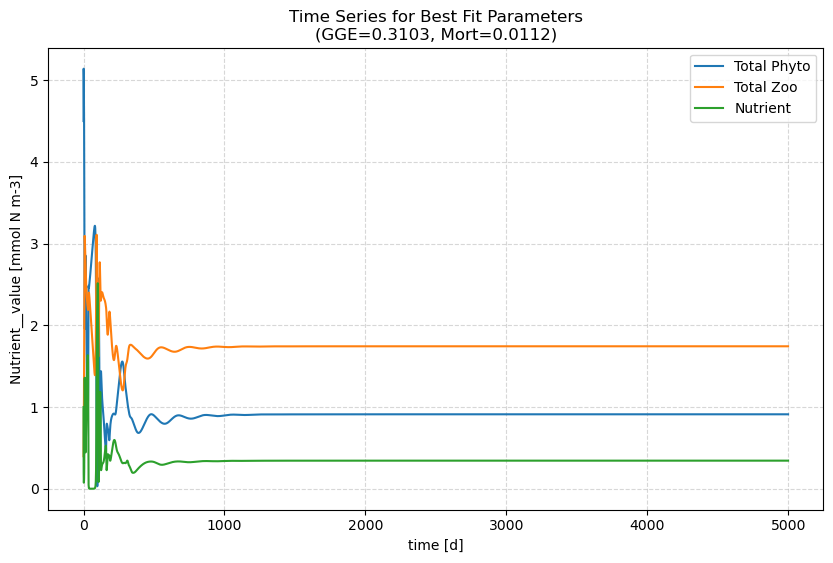

In [3]:
# --- Compute distance to target composition ---
rel_np = relative_composition.values
dist = np.linalg.norm(rel_np - target_composition, axis=2) 
print(f"Minimum distance found: {dist.min()}")

# --- Find the location (indices) of the minimum distance ---
# np.unravel_index converts the flat index from argmin into (row, col) indices
min_index_flat = np.nanargmin(dist) # Use nanargmin to ignore potential NaNs
min_index_2d = np.unravel_index(min_index_flat, dist.shape)

# Get the corresponding coordinate values (gge = row, mortality = col)
best_gge_value = biomass_mean['GGE__gge'].values[min_index_2d[0]]
best_mortality_value_scalar = biomass_mean['HigherOrderMortality__rate'].values[min_index_2d[1]]

print(f"Best fit found at index: {min_index_2d}")
print(f"Corresponding GGE__gge: {best_gge_value}")
print(f"Corresponding HigherOrderMortality__rate (scalar): {best_mortality_value_scalar}")

# --- Reconstruct the HigherOrderMortality__rate array for selection ---
# We need the full array [0, 0, 0, scalar_val] that was used as the coordinate
best_mortality_value_array = np.array([0., 0., 0., best_mortality_value_scalar])

# --- Extract the full time-series run for the best fit ---
# We need to use .sel() with the parameter values.
# For HigherOrderMortality__rate, we need to be careful as it's an array coordinate.
# A direct .sel() might struggle with the array. We can use isel() if we know the index.
# Or, if you stored the scalar version as the coordinate in final_ivp_results, use that.

# Assuming your final_ivp_results uses the *scalar* mortality value as the coordinate:
best_fit_run = final_ivp_results.sel(
    GGE__gge=best_gge_value, 
    HigherOrderMortality__rate=best_mortality_value_scalar, 
    method="nearest" # Use nearest in case of floating point issues
)

# --- Verification and Output ---
print("\n--- Best Fit Run Extracted ---")
print(best_fit_run)

# --- Optional: Plot the best fit time series ---
plt.figure(figsize=(10, 6))
best_fit_run['Phytoplankton__biomass'].sum(dim='phyto').plot.line(x='time', label='Total Phyto')
best_fit_run['Zooplankton__biomass'].sum(dim='zoo').plot.line(x='time', label='Total Zoo')
best_fit_run['Nutrient__value'].plot.line(x='time', label='Nutrient')
plt.title(f"Time Series for Best Fit Parameters\n(GGE={best_gge_value:.4f}, Mort={best_mortality_value_scalar:.4f})")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# --- (Your existing plotting code for the RGB map follows) ---
# ... (rest of your plotting code) ...

In [4]:
best_fit_params = {
    'GGE__gge': best_gge_value,
    'HigherOrderMortality__rate': best_mortality_value_array 
}
print(f"Running simulation with best fit parameters:\n{best_fit_params}")

Running simulation with best fit parameters:
{'GGE__gge': np.float64(0.3103448275862069), 'HigherOrderMortality__rate': array([0.        , 0.        , 0.        , 0.01120408])}


In [2]:

# --- 2. Calculate Mean of Last 1000 Steps ---
print("Calculating mean values for initial conditions...")
# Select variables and get the mean of the last 1000 time steps
mean_results = ivp_results[['Nutrient__value','Phytoplankton__biomass', 'Zooplankton__biomass']] \
                         .isel(time=slice(-1000, None)) \
                         .mean(dim='time')

print(mean_results)



Calculating mean values for initial conditions...
<xarray.Dataset> Size: 7kB
Dimensions:                     (N0__value: 10, HigherOrderMortality__rate: 10,
                                 phyto: 3, zoo: 4)
Coordinates:
  * HigherOrderMortality__rate  (HigherOrderMortality__rate) float64 80B 0.00...
  * N0__value                   (N0__value) float64 80B 0.002 ... 0.0055
  * phyto                       (phyto) float64 24B 0.63 6.3 63.0
  * zoo                         (zoo) float64 32B 6.3 63.0 630.0 6.3e+03
Data variables:
    Nutrient__value             (N0__value, HigherOrderMortality__rate) float64 800B ...
    Phytoplankton__biomass      (N0__value, HigherOrderMortality__rate, phyto) float64 2kB ...
    Zooplankton__biomass        (N0__value, HigherOrderMortality__rate, zoo) float64 3kB ...


In [3]:

# --- 3. Define the Initial Value Mapping ---
# Maps: {Variable name in mean_results} -> {Parameter name in model_setup_stability}
iv_map = {
    'Nutrient__value': 'Nutrient__value_init',
    'Phytoplankton__biomass':'Phytoplankton__biomass_init',
    'Zooplankton__biomass':'Zooplankton__biomass_init'
}

# --- 4. Run the Stability Scan ---
print("Running stability scan with dynamic initial values...")
stability_results = run_xso_stabilityscan(
    model_file_name='Stocketal2008',
    model_setup_name='model_setup_stability', # <-- Your stability setup
    param_name='HigherOrderMortality__rate',
    param_values=ivp_param_values,       # Must be the same parameter range
    param_name2='N0__value',
    param_values2=ivp_param_values2,     # Must be the same parameter range
    processes=20,
    initial_values_ds=mean_results,      # <-- Pass the mean results
    iv_mapping=iv_map                    # <-- Pass the name mapping
)

# Display the final result
if stability_results is not None:
    print("\nFinal Stability Scan Output Dataset:")
    print(stability_results)
    print("\nStability data:")
    print(stability_results['stability'])

PROGRESS: Completed 10/10 outer points. (HigherOrderMortality__rate = [0.   0.   0.   0.04]).

2D Stability Scan complete. Total Time taken: 2.93232 seconds.

Final Stability Scan Output Dataset:
<xarray.Dataset> Size: 177kB
Dimensions:                                         (N0__value: 10,
                                                     HigherOrderMortality__rate: 10,
                                                     zoo: 4, time: 2, phyto: 3,
                                                     full: 7, clock: 2)
Coordinates:
  * HigherOrderMortality__rate                      (HigherOrderMortality__rate) float64 80B ...
  * N0__value                                       (N0__value) float64 80B 0...
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 16B 0.0 1.0
  * zoo                                      

In [8]:
steady_states_for_init.sel(HigherOrderMortality__rate=0.02055556, method='nearest')

<xarray.Dataset> Size: 13kB
Dimensions:                                         (N0__value: 10, zoo: 4,
                                                     phyto: 3, full: 7, clock: 2)
Coordinates:
    HigherOrderMortality__rate                      float64 8B 0.02056
  * N0__value                                       (N0__value) float64 80B 0...
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * zoo                                             (zoo) float64 32B 6.3 ......
Dimensions without coordinates: full
Data variables: (12/57)
    Core__solver_type                               (N0__value) <U9 360B 'sta...
    GGE__R                                          (N0__value) float64 80B 0...
    GGE__alpha                                      (N0__value) float64 80B 0...
    GGE__assimilated_consumer                       (N0__value) <U1 40B 'Z' ....
    GGE__assimilation_value                         (N0__value, zoo) float64 320B ...
    GGE__egested_detritus                           (N0__value) <U1 40B 'N' ....
    ...                                              ...
    Zooplankton__biomass                            (N0__value, zoo) float64 320B ...
    Zooplankton__biomass_init                       (N0__value, zoo) float64 320B ...
    Zooplankton__biomass_label                      (N0__value) <U1 40B 'Z' ....
    Zooplankton__zoo_index                          (N0__value, zoo) float64 320B ...
    stability                                       (N0__value) object 80B 'u...
    max_eigenvalue                                  (N0__value) float64 80B 0...

In [5]:
# --- 3. Pre-process the stability_results Dataset ---
# We MUST select the final steady state (time=-1) AND
# drop the 'time' coordinate to prevent an alignment error.
print("Extracting steady states from 'stability_results' to use as new initial conditions...")
steady_states_for_init = stability_results.isel(time=-1).drop_vars('time')


# --- 4. Run the *NEW* IVP Scan ---
print("Running final solve_ivp scan initialized *from* steady states...")
new_ivp_results = run_xso_parscan( # <-- Using run_xso_parscan
    model_file_name='Stocketal2008',
    model_setup_name='model_setup_ivp', # <-- Your IVP setup
    param_name='HigherOrderMortality__rate',
    param_values=ivp_param_values,
    param_name2='N0__value',
    param_values2=ivp_param_values2,
    processes=20,
    initial_values_ds=steady_states_for_init, # <-- Pass the steady states
    iv_mapping=iv_map                       # <-- Pass the mapping
)

if new_ivp_results is None:
    raise RuntimeError("New IVP scan failed. Aborting.")

print("\n--- New IVP Scan Complete! ---")
print(new_ivp_results)

# --- 5. NEXT STEP: Create your RGB plot ---
# You can now use 'new_ivp_results' in your parameter fit plot.
# The 'NaN' regions should now be filled.
#
# (Your RGB plotting code would go here, using 'new_ivp_results')
#

Extracting steady states from 'stability_results' to use as new initial conditions...
Running final solve_ivp scan initialized *from* steady states...
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model' and setup 'model_setup_ivp' from 'Stocketal2008'...
Validation successful. Proceeding with scan.
Injecting initial values from dataset using mapping: {'Nutrient__value': 'Nutrient__value_init', 'Phytoplankton__biomass': 'Phytoplankton__biomass_init', 'Zooplankton__biomass': 'Zooplankton__biomass_init'}
--------------------------------
--- Using DEBUG version of _generate_iterable_tasks_2d ---
[Task_41] SKIPPING IC for Zooplankton__biomass_init: finite=True, plausible=False. Value was: [-1.50607952e-05  1.51966061e-02  8.87999999e-01  1.49688150e-02]. Using default.
[Task_42] SKIPPING IC for Phytoplankton__biomass_init: finite=True, plausible=False. Value was: [ 6.02418780e-66  1.93657140e+00 -1.61240689e-13]. Using default.
[Task_43] SKIPPING IC for Phytoplankton__biomas

/Users/aoop/Documents/GitHub/SSMCariaco/FirstTestRuns/ParameterScans/Stocketal2008_comps.py:184: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/SSMCariaco/FirstTestRuns/ParameterScans/Stocketal2008_comps.py:184: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/SSMCariaco/FirstTestRuns/ParameterScans/Stocketal2008_comps.py:184: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/SSMCariaco/FirstTestRuns/ParameterScans/Stocketal2008_comps.py:184: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * p

KeyboardInterrupt: 

In [8]:
model_setup

<xarray.Dataset> Size: 41kB
Dimensions:                           (clock: 2, phyto: 3, zoo: 4, full: 7,
                                       time: 5000)
Coordinates:
  * clock                             (clock) int64 16B 0 1
Dimensions without coordinates: phyto, zoo, full, time
Data variables: (12/42)
    Nutrient__value_label             <U1 4B 'N'
    Nutrient__value_init              float64 8B 1.0
    Phytoplankton__biomass_label      <U1 4B 'P'
    Phytoplankton__biomass_init       (phyto) float64 24B 1.5 1.5 1.5
    Phytoplankton__phyto_index        (phyto) float64 24B 0.63 6.3 63.0
    Zooplankton__biomass_label        <U1 4B 'Z'
    ...                                ...
    HigherOrderMortality__exponent    (zoo) int64 32B 0 0 0 1
    HigherOrderMortality__recycling   (zoo) float64 32B 0.0 0.0 0.0 0.5
    N0__forcing_label                 <U2 8B 'N0'
    N0__value                         float64 8B 0.0053
    Core__solver_type                 <U9 36B 'solve_ivp'
    Time__time_input                  (time) int64 40kB 0 1 2 ... 4997 4998 4999
Attributes:
    __xsimlab_output_vars__:  Nutrient__value,Phytoplankton__biomass,Zooplank...

In [10]:
# --- Example Manual Test (Revised) ---
import importlib
import numpy as np

# 1. Load the model objects
print("Loading model...")
model_module = importlib.import_module('Stocketal2008')
model = model_module.model
model_setup = model_module.model_setup_ivp # Use the IVP setup with defaults
print("Model loaded.")

# 2. Define the failing parameter values (replace with actual values if needed)
#    Using values seen just before the crash in your logs
failing_params = {
    'HigherOrderMortality__rate': np.array([0., 0., 0., 0.02055556]), 
    'N0__value': 0.005111 # Example value corresponding to the failing outer loop step
}
print(f"Testing with parameters: {failing_params}")

# 3. Prepare the model (applies parameters and default ICs)
print("\nPreparing model with failing parameters and default ICs...")
try:
    # Context manager ensures clean setup/teardown if needed
    with model: 
        # Update *only* the scan parameters
        prepared_model = model_setup.xsimlab.update_vars(input_vars=failing_params)
        print("Model prepared successfully.")

        # 4. Attempt to run one tiny step
        print("\nAttempting to run one tiny step (t=0 to t=1e-6)...")
        try:
            # Run simulation for a very short duration. 
            # We don't need the output, just to see if it starts.
            # Using run() without time_step might try to run the whole 5000 days.
            # Let's try specifying a short time array instead.
            short_time = np.array([0.0, 1])
            
            # Re-create the setup with the short time for this test
            test_setup = model_setup.xsimlab.update_vars(
                input_vars={**failing_params, 'Time__time_input': short_time}
            )
            
            with test_setup: # Use the updated setup
                 output = test_setup.xsimlab.run()
            
            print("\n>>> TEST SUCCEEDED: Running one tiny step worked. <<<")
            print("This suggests the 'y0 must be finite' error might be intermittent,")
            print("or happening slightly after t=0, or related to how the parallel")
            print("workers handle the model setup.")
            
        except ValueError as ve:
             if "All components of the initial state `y0` must be finite" in str(ve):
                 print(f"\n>>> PROBLEM CONFIRMED: Running one step failed immediately at t=0 <<<")
                 print(f"Error details: {ve}")
                 print("\nThis strongly suggests the default ICs + parameters cause non-finite derivatives at t=0.")
                 print("Check model equations for potential issues (division by zero, log(0), sqrt(negative))")
                 print("that occur *specifically* with the default initial state and these parameters.")
             else:
                 # Other ValueError
                 print(f"\n>>> UNEXPECTED VALUE ERROR during run: {ve} <<<")

        except Exception as e:
            # Catch any other type of error during the run
            print(f"\n>>> PROBLEM CONFIRMED: Running one step failed with a different error <<<")
            print(f"Error details: {type(e).__name__}: {e}")
            print("\nInvestigate this specific error in your model function.")


except Exception as e:
    # Catch errors during the model preparation (.update_vars) phase
    print(f"\nERROR: Failed even during model preparation.")
    print(f"Error details: {type(e).__name__}: {e}")

Loading model...
Model loaded.
Testing with parameters: {'HigherOrderMortality__rate': array([0.        , 0.        , 0.        , 0.02055556]), 'N0__value': 0.005111}

Preparing model with failing parameters and default ICs...
Model prepared successfully.

Attempting to run one tiny step (t=0 to t=1e-6)...

>>> TEST SUCCEEDED: Running one tiny step worked. <<<
This suggests the 'y0 must be finite' error might be intermittent,
or happening slightly after t=0, or related to how the parallel
workers handle the model setup.


In [ ]:
import numpy as np
import xarray as xr

def generate_random_ics(param1_name, param1_coords, 
                        param2_name, param2_coords,
                        state_var_shapes, 
                        max_values):
    """
    Creates an xarray.Dataset of random initial conditions for a 2D scan.

    Parameters
    ----------
    param1_name : str
        Name of the first scan coordinate (e.g., 'HigherOrderMortality__rate').
    param1_coords : array-like
        The scalar coordinate values for the first parameter.
    param2_name : str
        Name of the second scan coordinate (e.g., 'N0__value').
    param2_coords : array-like
        The coordinate values for the second parameter.
    state_var_shapes : dict
        Maps state variable names (from iv_map) to their dimension shapes.
        e.g., {'Nutrient__value': (), 
               'Phytoplankton__biomass': (3,), 
               'Zooplankton__biomass': (4,)}
    max_values : dict
        Maps state variable names to the maximum random value to generate.
        e.g., {'Nutrient__value': 10.0, ...}

    Returns
    -------
    xarray.Dataset
        A dataset with the scan coordinates, filled with random values.
    """
    
    # Get the shape of the 2D parameter grid
    grid_shape = (len(param2_coords), len(param1_coords))
    
    data_vars = {}
    for var_name, shape in state_var_shapes.items():
        # Full shape is (param2_shape, param1_shape) + state_var_shape
        full_shape = grid_shape + shape
        
        # Get the max value for this variable, default to 1.0
        max_val = max_values.get(var_name, 1.0)
        
        # Create random data
        rand_data = max_val * np.random.rand(*full_shape)
        
        # Get the full dimension names
        # e.g., ('N0__value', 'HigherOrderMortality__rate', 'phyto')
        # We must get these from the state_var_shapes dict in the model
        dims = (param2_name, param1_name) + tuple(f'dim_{i}' for i in range(len(shape)))
        
        # This is a bit of a hack; we assume the dim names
        # You may need to replace ('dim_0', 'dim_1') with ('phyto', 'zoo')
        # Let's try to be smarter...
        if var_name == 'Phytoplankton__biomass':
            dims = (param2_name, param1_name, 'phyto')
        elif var_name == 'Zooplankton__biomass':
            dims = (param2_name, param1_name, 'zoo')
        else: # Nutrient
            dims = (param2_name, param1_name)
            
        data_vars[var_name] = (dims, rand_data)

    # Create the coordinate dictionary
    coords = {
        param1_name: param1_coords,
        param2_name: param2_coords
    }
    # Add coordinates for state var dims
    if 'Phytoplankton__biomass' in state_var_shapes:
        coords['phyto'] = np.arange(state_var_shapes['Phytoplankton__biomass'][0])
    if 'Zooplankton__biomass' in state_var_shapes:
        coords['zoo'] = np.arange(state_var_shapes['Zooplankton__biomass'][0])

    return xr.Dataset(data_vars, coords=coords)

In [ ]:
def run_multistart_stability_scan(num_starts, 
                                   param1_name, param1_values, param1_coords,
                                   param2_name, param2_values,
                                   iv_map, state_var_shapes, max_values,
                                   **scan_kwargs):
    """
    Runs run_xso_stabilityscan multiple times with random initial conditions.

    Parameters
    ----------
    num_starts : int
        Number of random initial condition sets to try (e.g., 5).
    param1_name, param1_values, param1_coords :
        Scan parameters for the first dimension.
        'param1_values' is the raw list (with arrays)
        'param1_coords' is the scalar list for the xarray coordinates
    param2_name, param2_values :
        Scan parameters for the second dimension.
    iv_map : dict
        Mapping of {dataset_var_name: model_init_param_name}.
    state_var_shapes : dict
        Shapes of the state variables (for the generator).
    max_values : dict
        Max random values (for the generator).
    **scan_kwargs :
        Other arguments to pass to run_xso_stabilityscan
        (e.g., model_file_name, model_setup_name, processes).
        
    Returns
    -------
    xarray.Dataset
        A combined dataset with a new 'solution_id' dimension.
    """
    
    all_results = []
    
    for i in range(num_starts):
        print(f"--- Starting Multi-Start Run {i+1} of {num_starts} ---")
        
        # 1. Generate a new set of random initial conditions
        random_ics_ds = generate_random_ics(
            param1_name=param1_name,
            param1_coords=param1_coords,
            param2_name=param2_name,
            param2_coords=param2_values, # param2 is scalar
            state_var_shapes=state_var_shapes,
            max_values=max_values
        )
        
        # 2. Run the stability scan
        stability_results = run_xso_stabilityscan(
            param_name=param1_name,
            param_values=param1_values,
            param_name2=param2_name,
            param_values2=param2_values,
            initial_values_ds=random_ics_ds,
            iv_mapping=iv_map,
            **scan_kwargs 
        )
        
        # 3. If successful, add a 'solution_id' and save
        if stability_results is not None:
            stability_results = stability_results.assign_coords(solution_id=i)
            all_results.append(stability_results)
        else:
            print(f"Run {i+1} failed to complete.")
            
    if not all_results:
        print("All stability scans failed.")
        return None
        
    # 4. Combine all datasets along the new dimension
    print("Combining results from all runs...")
    combined_ds = xr.concat(all_results, dim='solution_id')
    return combined_ds

In [ ]:
import numpy as np
import xarray as xr
from xso.parscans import run_xso_parscan, run_xso_stabilityscan
# Make sure your helper functions from above are defined here


# This tells the generator what shapes to make
state_var_shapes = {
    'Nutrient__value': (),
    'Phytoplankton__biomass': (3,),
    'Zooplankton__biomass': (4,)
}

# This sets the *scale* of the random numbers (e.g., 0 to 10)
# Adjust these based on your model's expected scales!
max_values = {
    'Nutrient__value':1.5,
    'Phytoplankton__biomass': 5.5,
    'Zooplankton__biomass': 2.5
}

# --- 3. Run the Multi-Start Scan ---
N_STARTS = 15  # Try 5 different random starting points

# These are the keyword args for run_xso_stabilityscan
scan_kwargs = {
    'model_file_name': 'Stocketal2008',
    'model_setup_name': 'model_setup_stability',
    'processes': 20
}

all_solutions = run_multistart_stability_scan(
    num_starts=N_STARTS,
    param1_name='HigherOrderMortality__rate',
    param1_values=ivp_param_values,
    param1_coords=higherordermortality, # The scalar coords
    param2_name='N0__value',
    param2_values=ivp_param_values2,
    iv_map=iv_map,
    state_var_shapes=state_var_shapes,
    max_values=max_values,
    **scan_kwargs
)

# Display the result
if all_solutions is not None:
    print("\nFinal Combined Output Dataset:")
    print(all_solutions)

In [ ]:
# --- 4. Create the 2D "Best Solution" Dataset ---
print("Creating 2D 'best_solution' dataset from multi-start results...")

# Create 3D masks for stable and meaningful states
is_stable = (all_solutions['stability'] == 'stable')
steady_state = all_solutions.isel(time=-1)
threshold = 1e-6 
is_meaningful = (steady_state['Phytoplankton__biomass'].all(dim='phyto') > threshold) & \
                (steady_state['Zooplankton__biomass'].all(dim='zoo') > threshold) & \
                (steady_state['Nutrient__value'] > threshold)

# Combine the 3D masks
stable_and_meaningful_mask = is_stable & is_meaningful

# Create a 3D dataset that is NaN where solutions are not stable/meaningful
stable_solutions_3d = all_solutions.where(stable_and_meaningful_mask)

# --- "Collapse" the 3D dataset to 2D ---

# --- HIGHLIGHTED FIX ---
# 1. Select *only* the numeric state variables *before* filling.
#    The keys of iv_map are: ['Nutrient__value', 'Phytoplankton__biomass', ...]
numeric_steady_states_3d = stable_solutions_3d[list(iv_map.keys())]

# 2. Now, run bfill() *only* on this numeric subset.
best_solutions_2d = numeric_steady_states_3d.bfill(dim='solution_id').isel(solution_id=0, drop=True)
# --- END FIX ---


# --- Clean the dataset for use as initial conditions ---
# 1. Select the final steady-state time-slice
# 2. Drop the 'time' coordinate to prevent the alignment error
best_solutions_2d_cleaned = best_solutions_2d.isel(time=-1).drop_vars('time', errors='ignore')

print("2D 'best_solution' dataset created.")
print(best_solutions_2d_cleaned)

# --- 5. Run the Final 'solve_ivp' Scan ---
print("Running final 'solve_ivp' scan, initialized from 'best_solution' dataset...")

final_ivp_results = run_xso_parscan(
    model_file_name='Stocketal2008',
    model_setup_name='model_setup_ivp', # <-- Your IVP setup
    param_name='HigherOrderMortality__rate',
    param_values=ivp_param_values,
    param_name2='N0__value',
    param_values2=ivp_param_values2,
    processes=20,
    initial_values_ds=best_solutions_2d_cleaned, # <-- Pass the "best of" steady states
    iv_mapping=iv_map
)

if final_ivp_results is None:
    raise RuntimeError("Final IVP scan failed. Aborting.")

print("\n--- Final IVP Scan Complete! ---")
print(final_ivp_results)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import matplotlib.colors as mcolors

def _create_ivp_summary_map(ivp_ds, threshold=1e-6, osc_threshold=1e-4):
    """
    Helper function to convert an IVP timeseries dataset into a 2D
    stability-like summary map (stable=1, unstable=-1, washout=0).
    (This version prevents the RuntimeWarning)
    """
    
    # --- 1. Get stats from the end of the simulation ---
    last_1000_days_slice = ivp_ds.isel(time=slice(-1000, None))
    nutrient_slice = last_1000_days_slice['Nutrient__value']

    # --- HIGHLIGHTED FIX ---
    # Count non-NaN points first to avoid warning
    valid_points_count = nutrient_slice.count(dim='time')
    
    # Calculate std_dev only if there are enough points (>= 2)
    # We use xr.where to do this safely over the whole 2D grid
    std_dev = xr.where(
        valid_points_count > 1,          # Condition
        nutrient_slice.std(dim='time'),  # Value if True
        0.0                              # Value if False (std dev of 0 or 1 point is 0)
    )
    # --- END FIX ---
    
    final_state = ivp_ds.isel(time=-1)

    # --- 2. Create masks ---
    is_failed = final_state['Nutrient__value'].isnull()
    
    phyto_ok = final_state['Phytoplankton__biomass'].all(dim='phyto') > threshold
    zoo_ok = final_state['Zooplankton__biomass'].all(dim='zoo') > threshold
    nutrient_ok = final_state['Nutrient__value'] > threshold
    is_meaningful = phyto_ok & zoo_ok & nutrient_ok

    is_oscillating = (std_dev > osc_threshold)
    
    # --- 3. Build the 2D plot_array ---
    plot_array = xr.full_like(is_failed, np.nan, dtype=float)
    plot_array = xr.where(~is_failed & is_meaningful & ~is_oscillating, 1.0, plot_array) # Stable
    plot_array = xr.where(~is_failed & is_meaningful & is_oscillating, -1.0, plot_array) # Unstable
    washout_mask = xr.where(~is_failed & ~is_meaningful, 1.0, np.nan)
    
    return plot_array, washout_mask

# --- HELPER 2: For Multi-Start fsolve Scan (Unchanged) ---
def _create_multistart_summary_map(all_solutions, threshold=1e-6):
    """
    Helper function to convert a multi-start fsolve dataset into a 2D
    stability-like summary map (stable=1, unstable=-1, washout=0).
    """
    is_stable = (all_solutions['stability'] == 'stable')
    is_unstable = (all_solutions['stability'] == 'unstable')

    steady_state = all_solutions.isel(time=-1)
    phyto_ok = steady_state['Phytoplankton__biomass'].all(dim='phyto') > threshold
    zoo_ok = steady_state['Zooplankton__biomass'].all(dim='zoo') > threshold
    nutrient_ok = steady_state['Nutrient__value'] > threshold
    is_meaningful = phyto_ok & zoo_ok & nutrient_ok

    stable_and_meaningful = is_stable & is_meaningful
    unstable_and_meaningful = is_unstable & is_meaningful
    washout = ~is_meaningful

    has_stable_meaningful = stable_and_meaningful.any(dim='solution_id')
    has_unstable_meaningful = unstable_and_meaningful.any(dim='solution_id')
    
    has_only_washout = (washout.any(dim='solution_id') & 
                        ~has_stable_meaningful & 
                        ~has_unstable_meaningful)

    plot_array = xr.full_like(has_stable_meaningful, np.nan, dtype=float)
    plot_array = xr.where(has_stable_meaningful, 1.0, plot_array)
    plot_array = xr.where(~has_stable_meaningful & has_unstable_meaningful, -1.0, plot_array)
    washout_mask = xr.where(has_only_washout, 1.0, np.nan)

    return plot_array, washout_mask


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import matplotlib.colors as mcolors

# (Your two helper functions, _create_ivp_summary_map and 
# _create_multistart_summary_map, should be defined above this)

def plot_all_comparisons_4_panel(ivp_results_1, ivp_results_2, all_solutions, final_ivp_results):
    """
    Generates a 4-panel (2x2) comparison of the three main analysis steps
    with a single, shared colorbar at the top.
    """
    
    print("Generating 4-panel (2x2) comparison plot...")
    
    # --- 1. Process all datasets ---
    map1, washout_mask1 = _create_ivp_summary_map(ivp_results_1)
    map2, washout_mask2 = _create_ivp_summary_map(ivp_results_2)
    map3, washout_mask3 = _create_multistart_summary_map(all_solutions)
    map4, washout_mask4 = _create_ivp_summary_map(final_ivp_results)

    # --- 2. Create the 2x2 figure ---
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(
        2, 2, 
        figsize=(18, 14), 
        sharex=True, 
        sharey=True
    )
    
    # Common plotting kwargs - Note: add_colorbar=False for ALL
    plot_kwargs = {
        'cmap': 'coolwarm',
        'levels': [-1.5, -0.5, 0.5, 1.5],
        'zorder': 1,
        'add_colorbar': False 
    }

    # --- 3. Plot for ax1 (Original IVP) ---
    map1.plot(ax=ax1, **plot_kwargs)
    y_indices, x_indices = np.where(np.isfinite(washout_mask1.values))
    if len(x_indices) > 0:
        x_coords = washout_mask1['HigherOrderMortality__rate'].values[x_indices]
        y_coords = washout_mask1['N0__value'].values[y_indices]
        ax1.scatter(x_coords, y_coords, marker='x', color='black', s=100, zorder=2)
    ax1.set_title("1. Original IVP Scan (Default ICs)\n('x' = Washout, White = Failed/NaN)")

    # --- 4. Plot for ax2 (fsolve-IC IVP) ---
    map2.plot(ax=ax2, **plot_kwargs)
    y_indices_2, x_indices_2 = np.where(np.isfinite(washout_mask2.values))
    if len(x_indices_2) > 0:
        x_coords_2 = washout_mask2['HigherOrderMortality__rate'].values[x_indices_2]
        y_coords_2 = washout_mask2['N0__value'].values[y_indices_2]
        ax2.scatter(x_coords_2, y_coords_2, marker='x', color='black', s=100, zorder=2)
    ax2.set_title("2. fsolve-IC IVP Scan\n('x' = Washout, White = Failed/NaN)")

    # --- 5. Plot for ax3 (Multi-start fsolve) ---
    map3.plot(ax=ax3, **plot_kwargs)
    y_indices_3, x_indices_3 = np.where(np.isfinite(washout_mask3.values))
    if len(x_indices_3) > 0:
        x_coords_3 = washout_mask3['HigherOrderMortality__rate'].values[x_indices_3]
        y_coords_3 = washout_mask3['N0__value'].values[y_indices_3]
        ax3.scatter(x_coords_3, y_coords_3, marker='x', color='black', s=100, zorder=2)
    ax3.set_title("3. Multi-Start fsolve Scan\n('x' = Washout, White = All Failed)")

    # --- 6. Plot for ax4 (Final IVP from Multi-start) ---
    # We plot this one last so we can 'steal' its mappable artist for the colorbar
    p = map4.plot(ax=ax4, **plot_kwargs)
    
    y_indices_4, x_indices_4 = np.where(np.isfinite(washout_mask4.values))
    if len(x_indices_4) > 0:
        x_coords_4 = washout_mask4['HigherOrderMortality__rate'].values[x_indices_4]
        y_coords_4 = washout_mask4['N0__value'].values[y_indices_4]
        ax4.scatter(x_coords_4, y_coords_4, marker='x', color='black', s=100, zorder=2)
    ax4.set_title("4. Final IVP Scan (Multi-start ICs)\n('x' = Washout, White = Failed/NaN)")

    # --- 7. ADD SHARED COLORBAR ---
    # Manually adjust subplots to make room at the top
    fig.subplots_adjust(top=0.9) # Leave 10% space at the top

    # Create a new axes for the colorbar in that space
    # [left, bottom, width, height] in figure-fraction coordinates
    cbar_ax = fig.add_axes([0.15, 0.92, 0.7, 0.03])
    
    # Draw the colorbar
    cbar = fig.colorbar(
        p, # 'p' is the artist we captured from map4.plot()
        cax=cbar_ax, 
        orientation='horizontal',
        label='Inferred Behavior (1=Stable, -1=Oscillating)'
    )
    # Set the ticks to be in the middle of the colors
    cbar.set_ticks([-1, 1]) 
    
    # Optional: Set labels for the ticks
    # cbar.set_ticklabels(['Unstable/Oscillating', 'Stable']) 
    
    plt.show()

In [ ]:
# Assuming you have:
# ivp_results:       (your original IVP scan from default ICs)
# new_ivp_results: (your IVP scan from the *first* fsolve run)
# all_solutions:     (your multi-start fsolve scan from random ICs)
# final_ivp_results: (your IVP scan from the 'best of' multi-start)

plot_all_comparisons_4_panel(
    ivp_results,       # Plot 1
    new_ivp_results,   # Plot 2
    all_solutions,     # Plot 3
    final_ivp_results  # Plot 4
)

In [ ]:
#final_ivp_results.isel(N0__value=3, HigherOrderMortality__rate=2).Phytoplankton__biomass.plot.line(x='time')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import xarray as xr
import matplotlib.colors as mcolors

# (This helper function is from our previous step)
def _create_multistart_summary_map(all_solutions, threshold=1e-6):
    """
    Helper function to convert a multi-start fsolve dataset into a 2D
    stability-like summary map.
    """
    is_stable = (all_solutions['stability'] == 'stable')
    steady_state = all_solutions.isel(time=-1)
    is_meaningful = (steady_state['Phytoplankton__biomass'].all(dim='phyto') > threshold) & \
                    (steady_state['Zooplankton__biomass'].all(dim='zoo') > threshold) & \
                    (steady_state['Nutrient__value'] > threshold)
    
    stable_and_meaningful = is_stable & is_meaningful
    
    # We only care about one mask: "Is there a stable, meaningful state?"
    has_stable_meaningful = stable_and_meaningful.any(dim='solution_id')

    return has_stable_meaningful


# --- 1. GENERATE THE "FIT" DATA (from your IVP run) ---
# We use 'final_ivp_results' because it's the most complete IVP run
print("Calculating parameter fit from 'final_ivp_results'...")

target_composition = np.array([0.308, 0.290, 0.402])
start_time = 365 * 9
end_time = 365 * 10

# Slice and average over the last year
biomass = final_ivp_results.Phytoplankton__biomass.isel(time=slice(start_time, end_time))
biomass_mean = biomass.mean(dim='time')

# Transpose to match plot dimensions
biomass_mean = biomass_mean.transpose('HigherOrderMortality__rate', 'N0__value', 'phyto')

# Normalize to relative composition
total_biomass = biomass_mean.sum(dim='phyto')
relative_composition = biomass_mean / total_biomass
relative_composition = relative_composition.fillna(0)

# Compute distance to target composition
rel_np = relative_composition.values
dist = np.linalg.norm(rel_np - target_composition, axis=2)
print(f"Minimum distance found: {dist.min()}")

# Normalize and compute brightness for RGB plot
dist_max = np.percentile(dist, 95)
dist_clipped = np.clip(dist, 0, dist_max)
dist_norm = dist_clipped / dist_max
brightness = 1 - dist_norm
gamma = 0.5
brightness_gamma = brightness ** gamma
rgb = rel_np * brightness_gamma[..., np.newaxis]
rgb = np.nan_to_num(rgb, nan=0.0)
rgb = np.clip(rgb, 0, 1)

# Prepare coordinate grids for contour
x_vals = biomass_mean.N0__value.values
y_vals = biomass_mean.HigherOrderMortality__rate.values
X, Y = np.meshgrid(x_vals, y_vals)

# --- 2. GENERATE THE "STABILITY" MASK (from your fsolve run) ---
print("Calculating stability mask from 'all_solutions'...")

# This mask is True only for stable, meaningful regions
allowed_mask = _create_multistart_summary_map(all_solutions)

# We want to hatch everything *not* in this mask
disallowed_mask = ~allowed_mask

# --- 3. CREATE THE FINAL COMBINED PLOT ---
print("Generating final overlay plot...")

plt.figure(figsize=(10, 6))
ax = plt.gca()

# Plot the RGB composition/fit as the base
ax.imshow(rgb, origin='lower', aspect='auto',
          extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
          zorder=1)

# Overlay contour for perfect match
levels = [0.02, 0.05, 0.1, 0.2]
cmap = mcolors.LinearSegmentedColormap.from_list("grey_white", ["grey", "white"], N=256)
cs = ax.contour(X, Y, dist, levels=levels, colors=cmap(np.linspace(1, 0, len(levels))), 
                linewidths=1.5, zorder=3)

# --- OVERLAY STABILITY MASK ---
# Transpose the mask to match the (Y, X) dimension order of imshow
disallowed_mask_T = disallowed_mask.transpose('HigherOrderMortality__rate', 'N0__value')

# Plot hatches 'XX' over all "disallowed" (unstable, washout, failed) regions
disallowed_mask_T.plot.contourf(
    ax=ax,
    levels=[0.5, 1.5],     # Capture the 'True' values
    colors='none',         
    hatches=['XX'],        # Use 'XX' for a dense hatch
    add_colorbar=False,    
    zorder=2               
)
print("Overlaying all non-stable/non-meaningful regions with hatching...")

# --- 4. LEGEND AND FINAL PLOT ---
ax.set_xlabel('N0__value')
ax.set_ylabel('HigherOrderMortality__rate')
ax.set_title('Parameter Fit vs. Stability\nFind the brightest area that is NOT hatched')
ax.grid(False)

legend_elements = [
    Patch(facecolor='red', label='Phyto 1 dominates'),Patch(facecolor='green', label='Phyto 2 dominates'),
    Patch(facecolor='blue', label='Phyto 3 dominates'),
    Patch(facecolor='white', label='Contour: Good match to target'),
    Patch(facecolor='black', label='Dark: Poor match to target'),
    Patch(facecolor='grey', hatch='XX', label='Region is NOT Stable/Meaningful')
]
ax.legend(handles=legend_elements, loc='upper left')

plt.savefig("Final_Parameter_Fit_vs_Stability.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [6]:
import matplotlib.pyplot as plt
import numpy as np

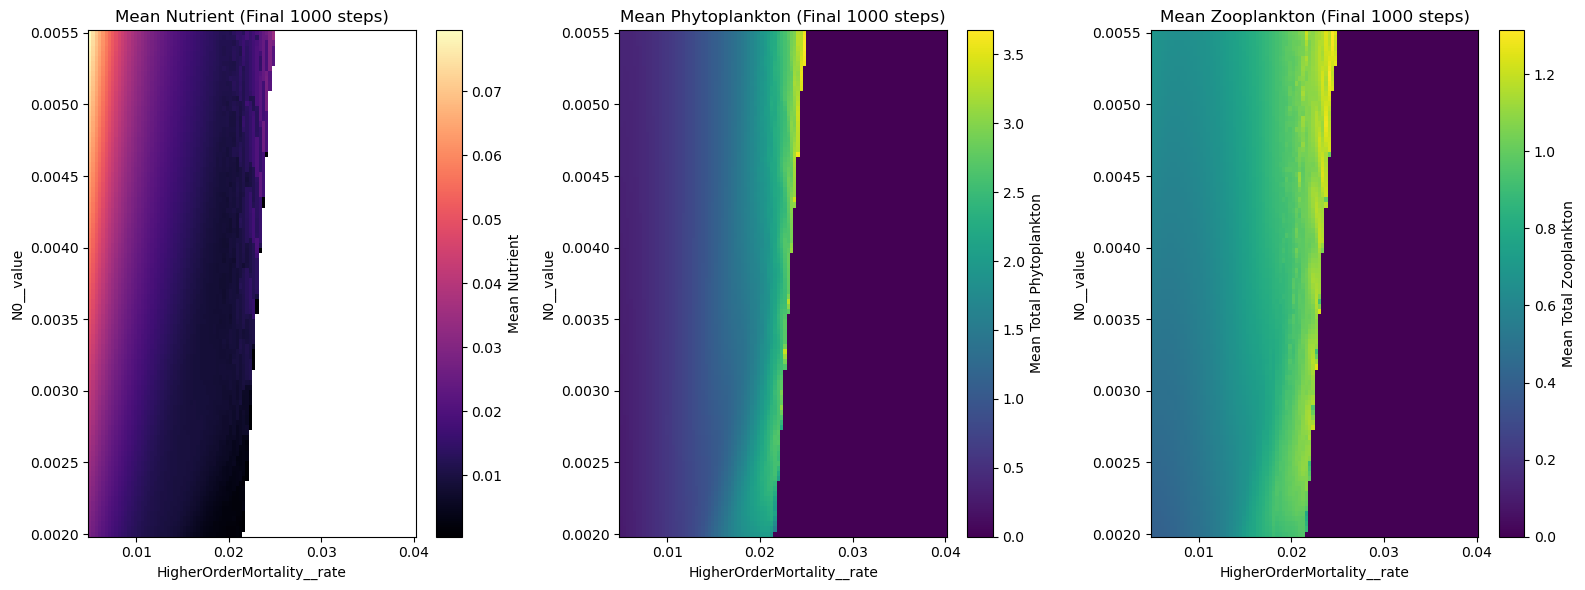

In [23]:
# Assuming 'mean_results' is your dataset with mean values
# and has variables 'Phytoplankton__biomass' and 'Nutrient__value'

# Create a figure with two subplots, side-by-side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))


# Plot 2: Nutrient mean value
mean_results['Nutrient__value'].plot(
    ax=ax1,
    cmap='magma',
    cbar_kwargs={'label': 'Mean Nutrient'}
)
ax1.set_title('Mean Nutrient (Final 1000 steps)')

# Plot 1: Phytoplankton mean value
# We sum over the 'phyto' dimension to get a single 2D value
mean_results['Phytoplankton__biomass'].sum(dim='phyto').plot(
    ax=ax2,
    cmap='viridis',  # 'cmap' sets the colormap
    cbar_kwargs={'label': 'Mean Total Phytoplankton'}
)
ax2.set_title('Mean Phytoplankton (Final 1000 steps)')


mean_results['Zooplankton__biomass'].sum(dim='zoo').plot(
    ax=ax3,
    cmap='viridis',  # 'cmap' sets the colormap
    cbar_kwargs={'label': 'Mean Total Zooplankton'}
)
ax3.set_title('Mean Zooplankton (Final 1000 steps)')

plt.tight_layout()

#plt.savefig("plots/Stability_output_solve_02.pdf", format='pdf', bbox_inches='tight')
plt.show()

Plotting 'x' markers at 2908 non-meaningful locations.


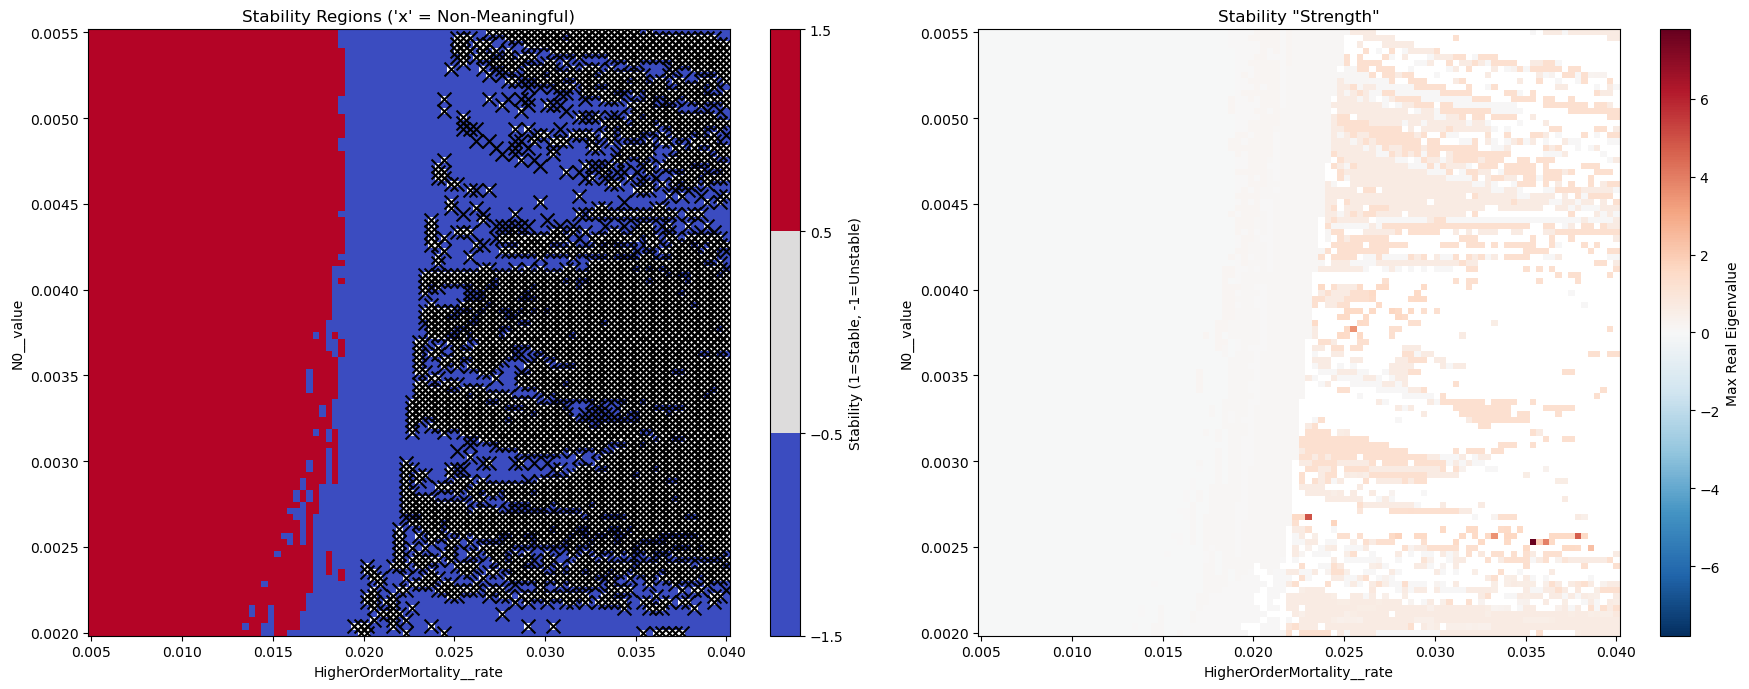

In [25]:

import xarray as xr
# --- HIGHLIGHTED FIX: Check for the 'None' object, not the string "None" ---
if stability_results is not None:
    # --- 1. CREATE THE BASE STABILITY PLOT ---
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    stability_map = {'stable': 1.0, 'unstable': -1.0, 'marginal': 0.0, np.nan: np.nan}
    numeric_stability = xr.apply_ufunc(lambda x: stability_map.get(x, np.nan), 
                                     stability_results['stability'], 
                                     vectorize=True)
    
    numeric_stability.plot(
        ax=ax1,
        cmap='coolwarm',
        levels=[-1.5, -0.5, 0.5, 1.5],
        cbar_kwargs={'label': 'Stability (1=Stable, -1=Unstable)'},
        zorder=1
    )

    # --- 2. CREATE THE "MEANINGFUL STATE" MASK ---
    
    steady_state = stability_results.isel(time=-1)
    threshold = 1e-6 
    
    phyto_ok = steady_state['Phytoplankton__biomass'].all(dim='phyto') > threshold
    zoo_ok = steady_state['Zooplankton__biomass'].all(dim='zoo') > threshold
    nutrient_ok = steady_state['Nutrient__value'] > threshold
    
    meaningful_mask = phyto_ok & zoo_ok & nutrient_ok
    non_meaningful_overlay = xr.where(meaningful_mask, np.nan, 1.0)

    # --- 3. ADD THE 'X' MARKER OVERLAY (ROBUST METHOD) ---
    
    # Find the indices of the cells to plot
    y_indices, x_indices = np.where(np.isfinite(non_meaningful_overlay.values))
    
    if len(x_indices) > 0:
        # Get the coordinate *values* at those indices
        x_coords = non_meaningful_overlay['HigherOrderMortality__rate'].values[x_indices]
        y_coords = non_meaningful_overlay['N0__value'].values[y_indices]
        
        # Use matplotlib's scatter directly
        ax1.scatter(
            x_coords, 
            y_coords, 
            marker='x', 
            color='black', 
            s=100,  # Adjust size as needed
            zorder=2
        )
        print(f"Plotting 'x' markers at {len(x_indices)} non-meaningful locations.")
    else:
        print("All steady states are ecologically meaningful. No 'x' markers to plot.")

    ax1.set_title("Stability Regions ('x' = Non-Meaningful)")

    # --- 4. PLOT MAX EIGENVALUE (UNCHANGED) ---
    
    stability_results['max_eigenvalue'].plot(
        ax=ax2,
        cmap='RdBu_r',
        center=0,
        cbar_kwargs={'label': 'Max Real Eigenvalue'}
    )
    ax2.set_title('Stability "Strength"')

    plt.tight_layout()
    
    #plt.savefig("plots/Stability_regions_02.pdf", format='pdf', bbox_inches='tight')
    plt.show()

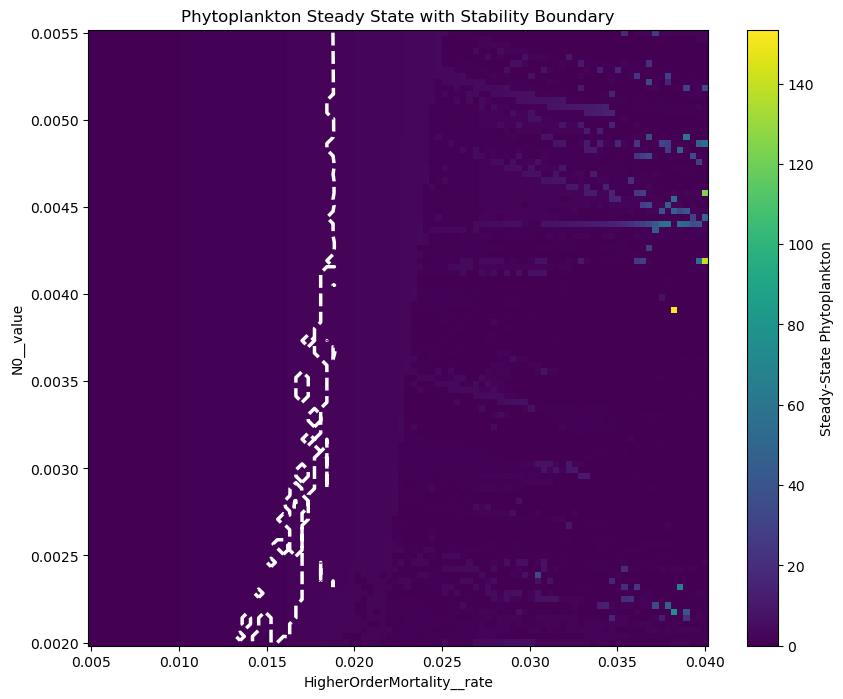

In [26]:
if stability_results is not None:
    plt.figure(figsize=(10, 8))

    # --- HIGHLIGHTED FIX ---
    # 1. Select the steady-state (the *final* time step)
    #    Then sum over the 'phyto' dimension
    steady_phyto = stability_results['Phytoplankton__biomass'].isel(time=-1).sum(dim='phyto')
    # --- END FIX ---
    
    steady_phyto.plot(
        cmap='viridis',
        cbar_kwargs={'label': 'Steady-State Phytoplankton'}
    )

    # 2. Overlay the stability boundary (this part was correct)
    stability_results['max_eigenvalue'].plot.contour(
        levels=[0],      # Only draw the contour at the 0-level
        colors='white',  # Make the line white
        linewidths=2.5,
        linestyles='--'   # Make the line dashed
    )

    plt.title('Phytoplankton Steady State with Stability Boundary')
    #plt.savefig("Stability_boundary_02.pdf", format='pdf', bbox_inches='tight')
    plt.show()

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import random

def plot_exemplary_timeseries(ivp_results, stability_results):
    """
    Finds and plots random example time-series from the ivp_results
    that correspond to stable, unstable, and washout steady states.

    Parameters
    ----------
    ivp_results : xarray.Dataset
        The 4D dataset from your 'run_xso_parscan' (time-series).
    stability_results : xarray.Dataset
        The 4D dataset from 'run_xso_stabilityscan' (stability map).
    """
    
    print("Finding exemplary time-series...")

    # --- 1. Re-create the masks from Plot 2 ---
    
    # Create numeric stability map
    stability_map = {'stable': 1.0, 'unstable': -1.0, 'marginal': 0.0, np.nan: np.nan}
    numeric_stability = xr.apply_ufunc(lambda x: stability_map.get(x, np.nan), 
                                     stability_results['stability'], 
                                     vectorize=True)
    
    # Create meaningful/washout mask
    steady_state = stability_results.isel(time=-1)
    threshold = 1e-6 
    phyto_ok = steady_state['Phytoplankton__biomass'].all(dim='phyto') > threshold
    zoo_ok = steady_state['Zooplankton__biomass'].all(dim='zoo') > threshold
    nutrient_ok = steady_state['Nutrient__value'] > threshold
    meaningful_mask = phyto_ok & zoo_ok & nutrient_ok

    # --- 2. Define the three category masks ---
    
    # Category 1: Stable AND meaningful (not washout)
    stable_mask = (numeric_stability == 1.0) & (meaningful_mask == True)
    
    # Category 2: Unstable AND meaningful (not washout)
    unstable_mask = (numeric_stability == -1.0) & (meaningful_mask == True)
    
    # Category 3: Washout (non-meaningful)
    washout_mask = (meaningful_mask == False)
    
    # --- 3. Helper function to get a random sample ---
    
    def _get_random_selector(mask):
        """Finds all points in a mask and returns a random one."""
        # Get coordinate names, e.g., ('N0__value', 'HigherOrderMortality__rate')
        dim1, dim2 = mask.dims
        
        # Get the 2D indices (y, x) of all 'True' points
        y_indices, x_indices = np.where(mask.values)
        
        if len(x_indices) == 0:
            return None, None  # No points found for this category
        
        # Pick one random index from the list of found points
        rand_idx = random.choice(range(len(x_indices)))
        sample_x_idx = x_indices[rand_idx]
        sample_y_idx = y_indices[rand_idx]
        
        # Get the coordinate *values* at that index
        p1_val = mask[dim2].values[sample_x_idx]
        p2_val = mask[dim1].values[sample_y_idx]
        
        # This is the dictionary we use with .sel()
        selector = {dim1: p2_val, dim2: p1_val}
        
        # Create a title for the plot
        title_str = f"{dim1}={p2_val:.4f}, {dim2}={p1_val:.4f}"
        
        return selector, title_str

    # --- 4. Get the three random selectors ---
    stable_sel, stable_title = _get_random_selector(stable_mask)
    unstable_sel, unstable_title = _get_random_selector(unstable_mask)
    washout_sel, washout_title = _get_random_selector(washout_mask)
    
    # --- 5. Create the plot ---
    fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True)
    
    # Plot 1: Stable
    if stable_sel:
        ts = ivp_results.sel(stable_sel)
        ts['Phytoplankton__biomass'].sum(dim='phyto').plot.line(x='time', ax=axes[0], label='Total Phyto')
        ts['Zooplankton__biomass'].sum(dim='zoo').plot.line(x='time', ax=axes[0], label='Total Zoo')
        ts['Nutrient__value'].plot.line(x='time', ax=axes[0], label='Nutrient')
        axes[0].set_title(f"Example 1: Stable & Meaningful\n({stable_title})")
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.5)
    else:
        axes[0].set_title("No 'Stable & Meaningful' points found")

    # Plot 2: Unstable
    if unstable_sel:
        ts = ivp_results.sel(unstable_sel)
        ts['Phytoplankton__biomass'].sum(dim='phyto').plot.line(x='time', ax=axes[1], label='Total Phyto')
        ts['Zooplankton__biomass'].sum(dim='zoo').plot.line(x='time', ax=axes[1], label='Total Zoo')
        ts['Nutrient__value'].plot.line(x='time', ax=axes[1], label='Nutrient')
        axes[1].set_title(f"Example 2: Unstable & Meaningful (Likely Oscillations)\n({unstable_title})")
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.5)
    else:
        axes[1].set_title("No 'Unstable & Meaningful' points found")

    # Plot 3: Washout
    if washout_sel:
        ts = ivp_results.sel(washout_sel)
        ts['Phytoplankton__biomass'].sum(dim='phyto').plot.line(x='time', ax=axes[2], label='Total Phyto')
        ts['Zooplankton__biomass'].sum(dim='zoo').plot.line(x='time', ax=axes[2], label='Total Zoo')
        ts['Nutrient__value'].plot.line(x='time', ax=axes[2], label='Nutrient')
        axes[2].set_title(f"Example 3: Washout / Non-Meaningful\n({washout_title})")
        axes[2].legend()
        axes[2].grid(True, linestyle='--', alpha=0.5)
    else:
        axes[2].set_title("No 'Washout' points found")
        
    plt.xlabel("Time")
    plt.tight_layout()
    
    #plt.savefig("Stability_exemplaryRuns_02.pdf", format='pdf', bbox_inches='tight')
    plt.show()

Finding exemplary time-series...


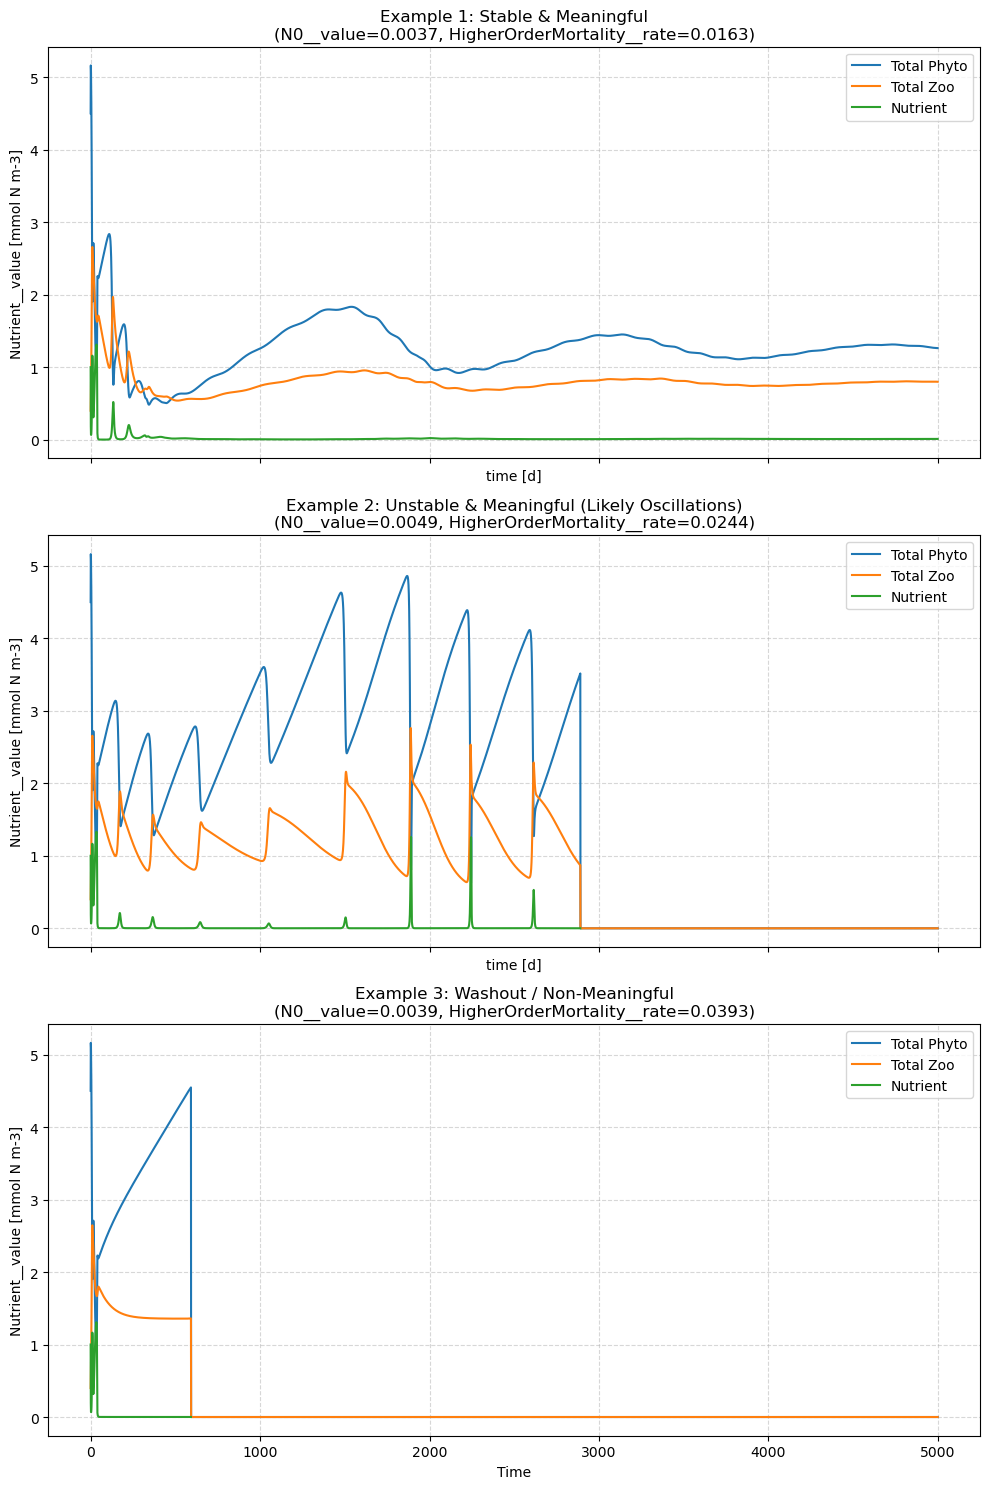

In [12]:
# Assuming you have:
# ivp_results (from run_xso_parscan)
# stability_results (from run_xso_stabilityscan)

plot_exemplary_timeseries(ivp_results, stability_results)

Generating 2D stability map from 'stability_results'...
Stability map for overlay generated.
Minimum distance found: 0.2993698978633119
Overlaying unstable regions with hatching...


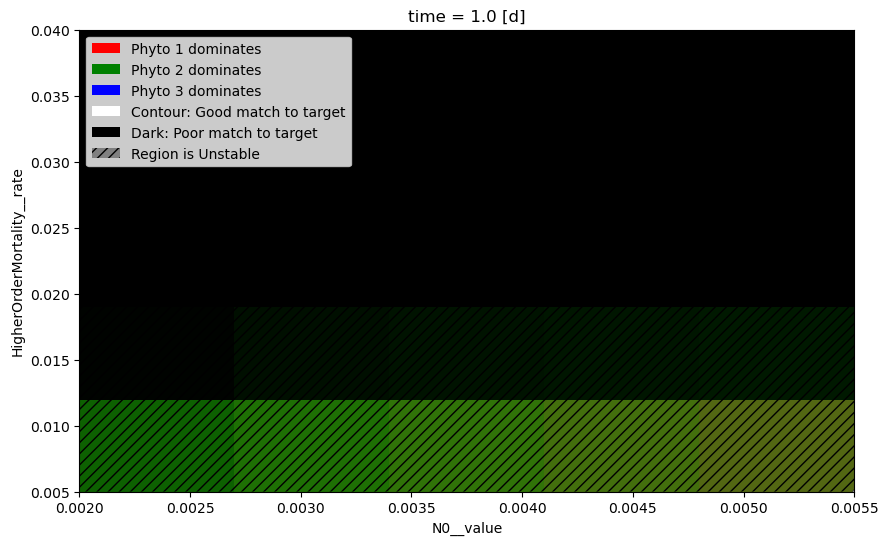

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import xarray as xr
import matplotlib.colors as mcolors

# --- Assumed Datasets ---
# ivp_results:       Your dataset from run_xso_parscan (the time-series).
# stability_results: Your dataset from run_xso_stabilityscan (the fsolve run).
# ------------------------


## 1. Generate the 2D Stability Map
# We convert your 2D 'stability_results' into the overlay masks.

print("Generating 2D stability map from 'stability_results'...")

# --- Create numeric map
# {'stable': 1.0, 'unstable': -1.0, 'marginal': 0.0, np.nan: np.nan}
stability_map = {'stable': 1.0, 'unstable': -1.0, 'marginal': 0.0, np.nan: np.nan}
numeric_stability = xr.apply_ufunc(lambda x: stability_map.get(x, np.nan),
                                 stability_results['stability'],
                                 vectorize=True)

# --- Create meaningful mask
steady_state = stability_results.isel(time=-1) # Select final state
threshold = 1e-6 
is_meaningful = (steady_state['Phytoplankton__biomass'].all(dim='phyto') > threshold) & \
                (steady_state['Zooplankton__biomass'].all(dim='zoo') > threshold) & \
                (steady_state['Nutrient__value'] > threshold)

# --- Build the 2D plot_array
# We get the stability value (1.0 or -1.0) *only* where it's meaningful
plot_array = numeric_stability.where(is_meaningful) 

# --- Create the specific mask for *only* unstable regions
# This will be used for the hatching
unstable_mask = (plot_array == -1.0)

print("Stability map for overlay generated.")


## 2. Generate the Parameter Fit Plot and Overlay Stability
# This is your plotting code, using 'ivp_results' and the 'unstable_mask'.

# --- Parameters ---
target_composition = np.array([0.402, 0.290, 0.308])
start_time = 365 * 9
end_time = 365 * 10

# --- Slice and average over the last year ---
# Use 'ivp_results' (your new dataset name)
biomass = ivp_results.Phytoplankton__biomass.isel(time=slice(start_time, end_time))
biomass_mean = biomass.mean(dim='time')

# Transpose so dimensions are (HigherOrderMortality__rate, N0__value, phyto)
biomass_mean = biomass_mean.transpose('HigherOrderMortality__rate', 'N0__value', 'phyto')

# --- Normalize each (i,j) point to relative composition ---
total_biomass = biomass_mean.sum(dim='phyto')
relative_composition = biomass_mean / total_biomass
relative_composition = relative_composition.fillna(0)

# --- Compute distance to target composition ---
rel_np = relative_composition.values
dist = np.linalg.norm(rel_np - target_composition, axis=2)
print(f"Minimum distance found: {dist.min()}")

# Normalize and compute brightness
dist_max = np.percentile(dist, 95)
dist_clipped = np.clip(dist, 0, dist_max)
dist_norm = dist_clipped / dist_max
brightness = 1 - dist_norm

# Apply gamma correction
gamma = 0.5
brightness_gamma = brightness ** gamma
rgb = rel_np * brightness_gamma[..., np.newaxis]

# Clean up RGB array for imshow
rgb = np.nan_to_num(rgb, nan=0.0)
rgb = np.clip(rgb, 0, 1)

# --- Prepare coordinate grids for contour ---
x_vals = biomass_mean.N0__value.values
y_vals = biomass_mean.HigherOrderMortality__rate.values
X, Y = np.meshgrid(x_vals, y_vals)

# --- Plot ---
plt.figure(figsize=(10, 6))
# Get the axis object for overlaying
ax = plt.gca()

# Plot the RGB composition/fit
ax.imshow(rgb, origin='lower', aspect='auto',
          extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
          zorder=1)

ax.set_xlabel('N0__value')
ax.set_ylabel('HigherOrderMortality__rate')
ax.set_title('Phytoplankton Composition Fit & System Stability\nRGB = Composition, Brightness = Fit, Hatched = Unstable')
ax.grid(False)

# Overlay contour for perfect match:
levels = [0.02, 0.05, 0.1, 0.3]
cmap = mcolors.LinearSegmentedColormap.from_list("grey_white", ["grey", "white"], N=256)
cs = ax.contour(X, Y, dist, levels=levels, colors=cmap(np.linspace(1, 0, len(levels))), 
                linewidths=1.5, zorder=3)


# --- !!! OVERLAY STABILITY MAP !!! ---

# We must transpose our 'unstable_mask' to match the (Y, X) dimension order
# of imshow, which is (HigherOrderMortality__rate, N0__value).
try:
    unstable_mask_T = unstable_mask.transpose('HigherOrderMortality__rate', 'N0__value')
    
    # Use xarray's contourf to plot *only* the hatching
    unstable_mask_T.plot.contourf(
        ax=ax,
        levels=[0.5, 1.5],     # This captures the 'True' (or 1.0) values
        colors='none',         # Do not draw a fill
        hatches=['///'],       # Draw diagonal hatches
        add_colorbar=False,    # No colorbar
        zorder=2               # Draw it on top of imshow, under fit contours
    )
    print("Overlaying unstable regions with hatching...")

except Exception as e:
    print(f"Could not overlay stability. Check dimension names. Error: {e}")

# --- Update Legend ---
legend_elements = [
    Patch(facecolor='red', label='Phyto 1 dominates'),
    Patch(facecolor='green', label='Phyto 2 dominates'),
    Patch(facecolor='blue', label='Phyto 3 dominates'),
    Patch(facecolor='white', label='Contour: Good match to target'),
    Patch(facecolor='black', label='Dark: Poor match to target'),
    Patch(facecolor='grey', hatch='///', label='Region is Unstable') # New patch
]
ax.legend(handles=legend_elements, loc='upper left')

#plt.savefig("ParScan_With_Stability_Overlay.pdf", format='pdf', bbox_inches='tight')
plt.show()